# m11b — Up Supplement, No Class Rebalancing

Same as m11 (GazeNetM5 + GazeCapture supplement + XGaze supplement) with one change:

- **m11**: supplement data + sqrt inverse frequency class weights → Up precision collapsed (0.55)
- **m11b**: supplement data + **no class weights** → let the data do the balancing work

Hypothesis: with 29k Up training samples (vs 4k in m5c), the model has enough signal without
the artificial thumb on the scale. Expected outcome: precision recovers toward m5c, recall
stays above m5c, better overall F1 on Up.

---
**Pre-flight checklist:**
- [ ] `gaze_labels_v2.csv` in `MyDrive/210/` ✓
- [ ] `geo_features_v2.parquet` in `MyDrive/210/` ✓
- [ ] Keta supplement tars in `MyDrive/210/gaze_wds_supplement/train/` ✓
- [ ] XGaze tars in `MyDrive/210/gaze_wds_balanced/train/` ✓

In [1]:
# ============================================================
# INSTALL
# ============================================================
!pip install webdataset -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 5.5 MB/s eta 0:00:00


In [2]:
# ============================================================
# MOUNT
# ============================================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
# ============================================================
# IMPORT TORCH
# ============================================================
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
NVIDIA A100-SXM4-80GB


In [4]:
# ============================================================
# IMPORTS
# ============================================================

import os, glob, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import webdataset as wds
from torchvision import transforms
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Imports loaded, device: {device}")

Imports loaded, device: cuda


In [5]:
# ============================================================
# ALL PATHS
# ============================================================

TAR_DIR_MAIN  = "/content/gaze_wds_balanced"
TAR_DIR_SUPP  = "/content/gaze_wds_supplement"

DRIVE_MAIN    = "/content/drive/MyDrive/210/gaze_wds_balanced"
DRIVE_SUPP    = "/content/drive/MyDrive/210/gaze_wds_supplement"

LABELS_CSV    = "/content/drive/MyDrive/210/gaze_labels_v2.csv"
GEO_PARQUET   = "/content/drive/MyDrive/210/geo_features_v2.parquet"

MODEL_NAME         = "m12a"
CHECKPOINT_BEST    = f"/content/drive/MyDrive/210/{MODEL_NAME}_best.pth"
CHECKPOINT_BESTGAP = f"/content/drive/MyDrive/210/{MODEL_NAME}_bestgap.pth"

print(f"Labels:               {LABELS_CSV}")
print(f"Geo:                  {GEO_PARQUET}")
print(f"Checkpoint (best):    {CHECKPOINT_BEST}")
print(f"Checkpoint (bestgap): {CHECKPOINT_BESTGAP}")

Labels:               /content/drive/MyDrive/210/gaze_labels_v2.csv
Geo:                  /content/drive/MyDrive/210/geo_features_v2.parquet
Checkpoint (best):    /content/drive/MyDrive/210/m12a_best.pth
Checkpoint (bestgap): /content/drive/MyDrive/210/m12a_bestgap.pth


In [6]:
# ============================================================
# COPY TARS TO LOCAL COLAB DISK
# ============================================================

for split in ['train', 'val', 'test']:
    local_dir = f'{TAR_DIR_MAIN}/{split}'
    os.makedirs(local_dir, exist_ok=True)
    source = f'{DRIVE_MAIN}/{split}/'
    for f in sorted(glob.glob(source + '*.tar')):
        dest = f"{local_dir}/{os.path.basename(f)}"
        if not os.path.exists(dest):
            os.system(f"cp '{f}' '{dest}'")
    count = len([f for f in os.listdir(local_dir) if f.endswith('.tar')])
    print(f"main/{split}: {count} tars")

supp_local = f'{TAR_DIR_SUPP}/train'
os.makedirs(supp_local, exist_ok=True)
for f in sorted(glob.glob(f'{DRIVE_SUPP}/train/*.tar')):
    dest = f"{supp_local}/{os.path.basename(f)}"
    if not os.path.exists(dest):
        os.system(f"cp '{f}' '{dest}'")
count = len([f for f in os.listdir(supp_local) if f.endswith('.tar')])
print(f"supplement/train: {count} tars")

main/train: 75 tars
main/val: 16 tars
main/test: 16 tars
supplement/train: 6 tars


In [7]:
# ============================================================
# VERIFY FILES
# ============================================================

main_train_tars = sorted(glob.glob(f"{TAR_DIR_MAIN}/train/*.tar"))
supp_train_tars = sorted(glob.glob(f"{TAR_DIR_SUPP}/train/*.tar"))
val_tar_urls    = sorted(glob.glob(f"{TAR_DIR_MAIN}/val/*.tar"))
test_tar_urls   = sorted(glob.glob(f"{TAR_DIR_MAIN}/test/*.tar"))

train_tar_urls = main_train_tars + supp_train_tars

print(f"Main train tars:  {len(main_train_tars)}")
print(f"Supp train tars:  {len(supp_train_tars)}")
print(f"Total train tars: {len(train_tar_urls)}")
print(f"Val tars:         {len(val_tar_urls)}")
print(f"Test tars:        {len(test_tar_urls)}")
print(f"Labels CSV:       {os.path.exists(LABELS_CSV)}")
print(f"Geo parquet:      {os.path.exists(GEO_PARQUET)}")

assert len(supp_train_tars) > 0, "No supplement tars found."
assert os.path.exists(LABELS_CSV), "gaze_labels_v2.csv not found."
assert os.path.exists(GEO_PARQUET), "geo_features_v2.parquet not found."

Main train tars:  75
Supp train tars:  6
Total train tars: 81
Val tars:         16
Test tars:        16
Labels CSV:       True
Geo parquet:      True


In [8]:
# ============================================================
# LOAD LABELS (v2)
# ============================================================

label_map_4   = {'Up': 0, 'Down': 1, 'Left': 2, 'Right': 3}
VALID_CLASSES = set(label_map_4.keys())

df_labels = pd.read_csv(LABELS_CSV)
print(f"Loaded {len(df_labels)} labeled frames")
print(df_labels['label'].value_counts())

label_lookup_4 = {
    row['key']: row['label']
    for _, row in df_labels.iterrows()
    if row['label'] in VALID_CLASSES
}
print(f"\nLabel lookup: {len(label_lookup_4)} entries")

Loaded 625293 labeled frames
label
Down     214504
Left     189839
Right    181163
Up        39787
Name: count, dtype: int64

Label lookup: 625293 entries


In [9]:
# ============================================================
# LOAD GEO FEATURES (v2)
# ============================================================

df_geo = pd.read_parquet(GEO_PARQUET)
print(f"Loaded geo features: {len(df_geo)} rows")

geo_cols = ['left_iris_h', 'right_iris_h', 'iris_h_agreement',
            'head_yaw', 'head_pitch', 'z_tilt', 'z_nose_rel']

geo_lookup = {}
for _, row in df_geo.iterrows():
    geo_lookup[row['key']] = row[geo_cols].values.astype(np.float32)

print(f"Geo lookup: {len(geo_lookup)} entries")

matched = sum(1 for k in label_lookup_4 if k in geo_lookup)
missing = len(label_lookup_4) - matched
print(f"\nGeo coverage: {matched}/{len(label_lookup_4)} ({100*matched/len(label_lookup_4):.1f}%)")
if missing > 0:
    print(f"  {missing} samples will use GEO_DEFAULT fallback")

GEO_DEFAULT = np.array([0.5, 0.5, 0.0, 0.0, 0.35, -0.1, -0.26], dtype=np.float32)
print(f"Geo default: {GEO_DEFAULT}")

Loaded geo features: 298538 rows
Geo lookup: 298538 entries

Geo coverage: 220379/625293 (35.2%)
  404914 samples will use GEO_DEFAULT fallback
Geo default: [ 0.5   0.5   0.    0.    0.35 -0.1  -0.26]


In [10]:
# ============================================================
# IMAGE TRANSFORMS (identical to m5c / m11)
# ============================================================

eye_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_aug = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

eye_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

face_transform_clean = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print("Transforms defined")

Transforms defined


In [11]:
# ============================================================
# make_dataset_4class (identical to m11)
# ============================================================

def make_dataset_4class(tar_urls, eye_transform, face_transform, shuffle=True):

    def filter_and_transform(sample):
        key = sample["__key__"]

        label_str = label_lookup_4.get(key)
        if label_str is None:
            return None

        face      = np.array(sample["face.jpg"])
        left_eye  = np.array(sample["left.jpg"])
        right_eye = np.array(sample["right.jpg"])

        if eye_transform:
            left_eye  = eye_transform(left_eye)
            right_eye = eye_transform(right_eye)
        if face_transform:
            face = face_transform(face)

        geo_features = geo_lookup.get(key)
        if geo_features is None:
            geo_features = GEO_DEFAULT.copy()

        return {
            'left_eye':     left_eye,
            'right_eye':    right_eye,
            'face':         face,
            'geo_features': torch.tensor(geo_features, dtype=torch.float32),
            'label':        torch.tensor(label_map_4[label_str], dtype=torch.long),
        }

    dataset = (
        wds.WebDataset(tar_urls, shardshuffle=1000 if shuffle else False)
        .shuffle(50000 if shuffle else 0)
        .decode("pil")
        .map(filter_and_transform)
        .select(lambda x: x is not None)
    )

    return dataset

print("make_dataset_4class defined")

make_dataset_4class defined


In [12]:
# ============================================================
# GazeNetM5 — Model Definition (unchanged)
# ============================================================

class GazeNetM5(nn.Module):
    def __init__(self, num_classes=4, geo_feat_dim=7):
        super(GazeNetM5, self).__init__()

        self.eye_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.face_cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=5, padding=2), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.geo_mlp = nn.Sequential(
            nn.Linear(geo_feat_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 64), nn.ReLU(),
        )

        self.fc = nn.Sequential(
            nn.Linear(4608 * 2 + 2304 + 64, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, left_eye, right_eye, face, geo_features):
        left_feat  = self.eye_cnn(left_eye).view(left_eye.size(0), -1)
        right_feat = self.eye_cnn(right_eye).view(right_eye.size(0), -1)
        face_feat  = self.face_cnn(face).view(face.size(0), -1)
        geo_feat   = self.geo_mlp(geo_features)
        combined   = torch.cat([left_feat, right_feat, face_feat, geo_feat], dim=1)
        return self.fc(combined)

print("GazeNetM5 defined")
_test = GazeNetM5(num_classes=4)
print(f"Parameters: {sum(p.numel() for p in _test.parameters()):,}")
del _test

GazeNetM5 defined
Parameters: 6,586,820


train: 160192 samples — {0: 17655, 1: 54143, 2: 45215, 3: 43179}
val: 28282 samples — {0: 912, 1: 11055, 2: 8644, 3: 7671}
test: 29770 samples — {0: 867, 1: 11016, 2: 9236, 3: 8651}


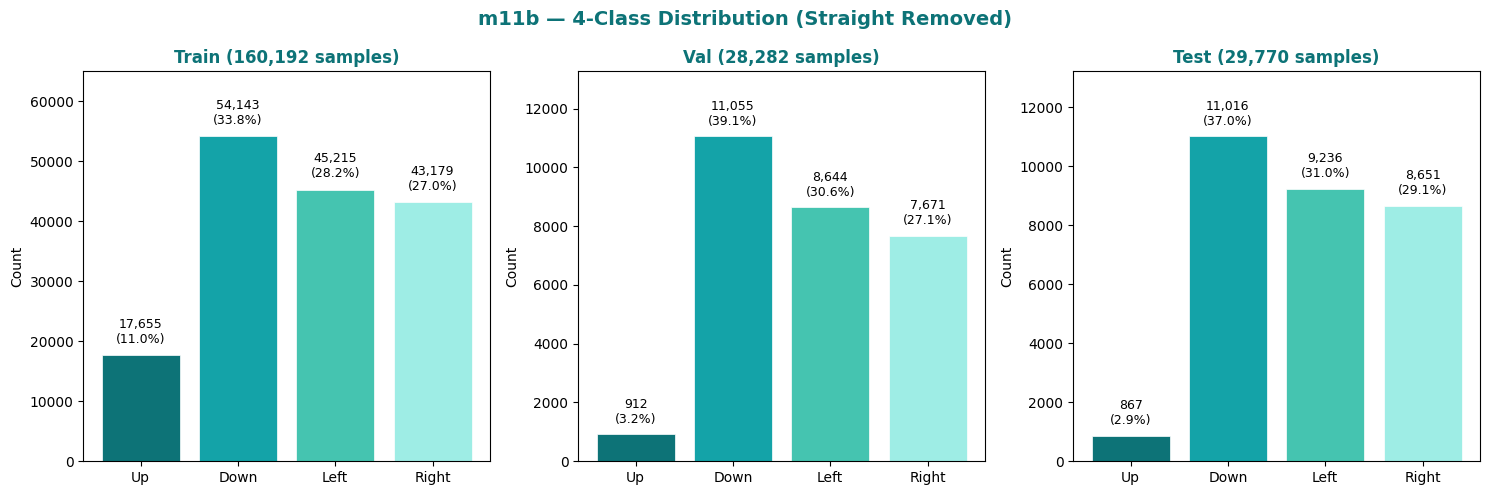

In [13]:
# ============================================================
# CHECK CLASS BALANCE
# Informational only — no weights to update for m11b.
# ============================================================

label_names_map = {0: 'Up', 1: 'Down', 2: 'Left', 3: 'Right'}
teal_colors = ['#0D7377', '#14A3A8', '#45C4B0', '#9EEDE5']

train_dataset_check = make_dataset_4class(train_tar_urls, eye_transform_clean, face_transform_clean, shuffle=False)
val_dataset_check   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset_check  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader_check = wds.WebLoader(train_dataset_check, batch_size=64, num_workers=2)
val_loader_check   = wds.WebLoader(val_dataset_check,   batch_size=64, num_workers=2)
test_loader_check  = wds.WebLoader(test_dataset_check,  batch_size=64, num_workers=2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (split_name, loader) in zip(axes, [
    ('train', train_loader_check),
    ('val',   val_loader_check),
    ('test',  test_loader_check),
]):
    counts = {i: 0 for i in range(4)}
    total = 0
    for batch in loader:
        for lbl in batch['label'].tolist():
            counts[lbl] += 1
            total += 1

    class_names  = [label_names_map[i] for i in range(4)]
    class_counts = [counts[i] for i in range(4)]
    bars = ax.bar(class_names, class_counts, color=teal_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(f'{split_name.capitalize()} ({total:,} samples)', fontsize=12,
                 fontweight='bold', color='#0D7377')
    ax.set_ylabel('Count')
    for bar, c in zip(bars, class_counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{c:,}\n({100*c/total:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_ylim(0, max(class_counts) * 1.2)
    print(f"{split_name}: {total} samples — {counts}")

plt.suptitle('m11b — 4-Class Distribution (Straight Removed)', fontsize=14,
             fontweight='bold', color='#0D7377')
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# MODEL SETUP — NO class weights
#
# Key difference from m11: CrossEntropyLoss without weight=
# The supplement data itself provides the Up class signal.
# ============================================================

train_dataset = make_dataset_4class(train_tar_urls, eye_transform_aug,   face_transform_aug,   shuffle=True)
val_dataset   = make_dataset_4class(val_tar_urls,   eye_transform_clean, face_transform_clean, shuffle=False)
test_dataset  = make_dataset_4class(test_tar_urls,  eye_transform_clean, face_transform_clean, shuffle=False)

train_loader = wds.WebLoader(train_dataset, batch_size=32, num_workers=2, pin_memory=True)
val_loader   = wds.WebLoader(val_dataset,   batch_size=32, num_workers=2, pin_memory=True)
test_loader  = wds.WebLoader(test_dataset,  batch_size=32, num_workers=2, pin_memory=True)

model = GazeNetM5(num_classes=4).to(device)

# NO class weights — label smoothing only
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Loss: CrossEntropyLoss(label_smoothing=0.1)  — no class weights")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"FC output shape: {model.fc[-1].weight.shape}  <-- should be [4, 256]")

Model: m12a
Device: cuda
Loss: CrossEntropyLoss(label_smoothing=0.1)  — no class weights
Parameters: 6,586,820
FC output shape: torch.Size([4, 256])  <-- should be [4, 256]


In [15]:
# ============================================================
# SMOKE TEST
# ============================================================

for label, tar in [('main', main_train_tars[0]), ('supplement', supp_train_tars[0])]:
    test_ds = make_dataset_4class([tar], eye_transform_clean, face_transform_clean, shuffle=False)
    smoke_loader = wds.WebLoader(test_ds, batch_size=4, num_workers=0)
    batch = next(iter(smoke_loader))
    print(f"[{label}] labels: {batch['label'].tolist()} — "
          f"face={batch['face'].shape}, geo={batch['geo_features'].shape}")

    model.eval()
    with torch.no_grad():
        out = model(
            batch['left_eye'].to(device),
            batch['right_eye'].to(device),
            batch['face'].to(device),
            batch['geo_features'].to(device),
        )
    print(f"  Output shape: {out.shape}  <-- should be [4, 4]")

print("\nSmoke test passed!")

[main] labels: [1, 1, 1, 1] — face=torch.Size([4, 3, 112, 112]), geo=torch.Size([4, 7])
  Output shape: torch.Size([4, 4])  <-- should be [4, 4]
[supplement] labels: [2, 0, 1, 1] — face=torch.Size([4, 3, 112, 112]), geo=torch.Size([4, 7])
  Output shape: torch.Size([4, 4])  <-- should be [4, 4]

Smoke test passed!


In [16]:
# ============================================================
# TRAINING LOOP
#
# Two checkpoints:
#   _best.pth    — lowest val loss
#   _bestgap.pth — smallest train-val gap while val acc > 90%
# ============================================================

num_epochs       = 20
patience         = 6
patience_counter = 0
best_val_loss    = float('inf')
best_gap         = float('inf')
best_gap_epoch   = -1

train_losses     = []
val_losses       = []
train_accuracies = []
val_accuracies   = []

for epoch in range(num_epochs):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"{'='*50}")

    # ---- Training ----
    model.train()
    train_loss    = 0.0
    train_correct = 0
    train_total   = 0
    epoch_start   = time.time()

    for batch_idx, batch in enumerate(train_loader):
        left_eye     = batch['left_eye'].to(device)
        right_eye    = batch['right_eye'].to(device)
        face         = batch['face'].to(device)
        geo_features = batch['geo_features'].to(device)
        labels       = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(left_eye, right_eye, face, geo_features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        _, predicted   = torch.max(outputs, 1)
        train_total   += labels.size(0)
        train_correct += (predicted == labels).sum().item()

        if (batch_idx + 1) % 1000 == 0:
            elapsed = time.time() - epoch_start
            eta = (elapsed / (batch_idx + 1)) * (7000 - (batch_idx + 1)) / 60
            print(f"  Batch {batch_idx+1}/~7000 — Loss: {loss.item():.4f} — ETA: {eta:.1f} min")

    avg_train_loss = train_loss / (batch_idx + 1)
    train_acc      = 100 * train_correct / train_total

    # ---- Validation ----
    model.eval()
    val_loss        = 0.0
    val_correct     = 0
    val_total       = 0
    val_batch_count = 0

    with torch.no_grad():
        for batch in val_loader:
            val_batch_count += 1
            outputs = model(
                batch['left_eye'].to(device),
                batch['right_eye'].to(device),
                batch['face'].to(device),
                batch['geo_features'].to(device),
            )
            loss = criterion(outputs, batch['label'].to(device))
            val_loss    += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total   += batch['label'].size(0)
            val_correct += (predicted == batch['label'].to(device)).sum().item()

    avg_val_loss = val_loss / val_batch_count
    val_acc      = 100 * val_correct / val_total
    gap          = train_acc - val_acc

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    scheduler.step(avg_val_loss)

    print(f"\n  Time:       {(time.time()-epoch_start)/60:.1f} min")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"  Gap:        {gap:.2f}%")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), CHECKPOINT_BEST)
        print(f"  ✓ Saved _best.pth (val_loss={avg_val_loss:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

    if val_acc >= 90.0 and gap < best_gap:
        best_gap       = gap
        best_gap_epoch = epoch + 1
        torch.save(model.state_dict(), CHECKPOINT_BESTGAP)
        print(f"  ✓ Saved _bestgap.pth (gap={gap:.2f}%, val_acc={val_acc:.2f}%)")

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}.")
        break

print(f"\nTraining complete!")
print(f"Best val loss:  {best_val_loss:.4f}")
print(f"Best gap epoch: {best_gap_epoch} (gap={best_gap:.2f}%)")


Epoch 1/20
  Batch 1000/~7000 — Loss: 1.1590 — ETA: 13.4 min
  Batch 2000/~7000 — Loss: 0.6998 — ETA: 11.0 min
  Batch 3000/~7000 — Loss: 0.5300 — ETA: 8.7 min
  Batch 4000/~7000 — Loss: 0.6789 — ETA: 6.3 min
  Batch 5000/~7000 — Loss: 0.4935 — ETA: 4.2 min

  Time:       11.4 min
  Train Loss: 0.7224 | Train Acc: 81.51%
  Val Loss:   0.5825 | Val Acc:   89.16%
  Gap:        -7.64%
  ✓ Saved _best.pth (val_loss=0.5825)

Epoch 2/20
  Batch 1000/~7000 — Loss: 0.6416 — ETA: 13.2 min
  Batch 2000/~7000 — Loss: 0.6060 — ETA: 11.0 min
  Batch 3000/~7000 — Loss: 0.5521 — ETA: 8.6 min
  Batch 4000/~7000 — Loss: 0.5695 — ETA: 6.3 min
  Batch 5000/~7000 — Loss: 0.4942 — ETA: 4.2 min

  Time:       11.4 min
  Train Loss: 0.5653 | Train Acc: 90.11%
  Val Loss:   0.5488 | Val Acc:   90.13%
  Gap:        -0.02%
  ✓ Saved _best.pth (val_loss=0.5488)
  ✓ Saved _bestgap.pth (gap=-0.02%, val_acc=90.13%)

Epoch 3/20
  Batch 1000/~7000 — Loss: 0.5527 — ETA: 13.1 min
  Batch 2000/~7000 — Loss: 0.5563 — ET

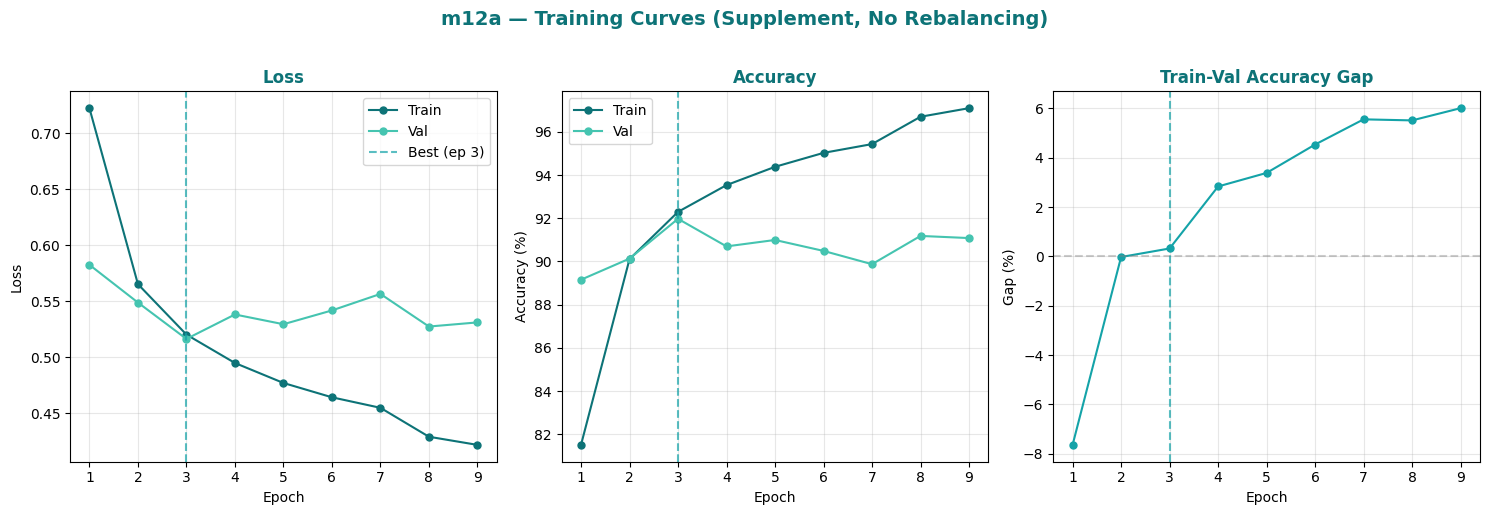


Training Summary (at best checkpoint)
Best epoch:        3
Best val loss:     0.5163
Val acc at best:   91.97%
Train acc at best: 92.29%
Gap at best:       0.32%
Best gap epoch:    2 (gap=-0.02%)


In [17]:
# ============================================================
# TRAINING CURVES — Teal theme, 3-panel
# ============================================================

teal_dark  = '#0D7377'
teal_mid   = '#14A3A8'
teal_light = '#45C4B0'

best_epoch   = val_losses.index(min(val_losses)) + 1
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.plot(epochs_range, train_losses, '-o', color=teal_dark,  label='Train', markersize=5)
ax.plot(epochs_range, val_losses,   '-o', color=teal_light, label='Val',   markersize=5)
ax.axvline(x=best_epoch, color=teal_mid, linestyle='--', alpha=0.7, label=f'Best (ep {best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss', fontweight='bold', color=teal_dark)
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs_range, train_accuracies, '-o', color=teal_dark,  label='Train', markersize=5)
ax.plot(epochs_range, val_accuracies,   '-o', color=teal_light, label='Val',   markersize=5)
ax.axvline(x=best_epoch, color=teal_mid, linestyle='--', alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy', fontweight='bold', color=teal_dark)
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[2]
gap_curve = [train_accuracies[i] - val_accuracies[i] for i in range(len(train_accuracies))]
ax.plot(epochs_range, gap_curve, '-o', color=teal_mid, markersize=5)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.4)
ax.axvline(x=best_epoch, color=teal_mid, linestyle='--', alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Gap (%)')
ax.set_title('Train-Val Accuracy Gap', fontweight='bold', color=teal_dark)
ax.grid(True, alpha=0.3)

plt.suptitle(f'{MODEL_NAME} — Training Curves (Supplement, No Rebalancing)',
             fontsize=14, fontweight='bold', color=teal_dark, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("Training Summary (at best checkpoint)")
print("="*50)
print(f"Best epoch:        {best_epoch}")
print(f"Best val loss:     {min(val_losses):.4f}")
print(f"Val acc at best:   {val_accuracies[best_epoch-1]:.2f}%")
print(f"Train acc at best: {train_accuracies[best_epoch-1]:.2f}%")
print(f"Gap at best:       {train_accuracies[best_epoch-1] - val_accuracies[best_epoch-1]:.2f}%")
print(f"Best gap epoch:    {best_gap_epoch} (gap={best_gap:.2f}%)")

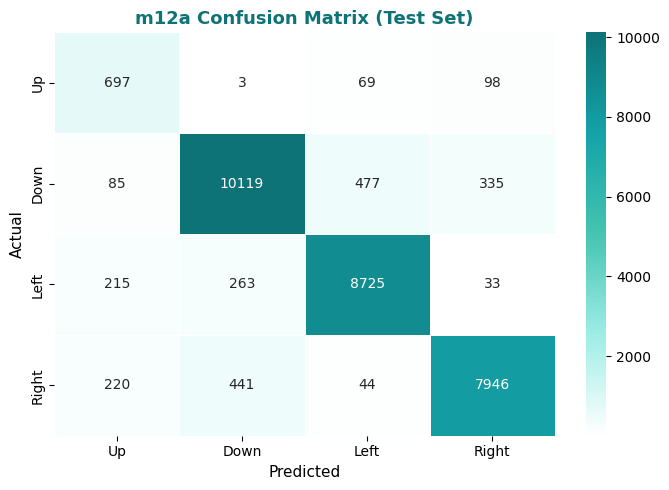


m12a Test Set Performance
              precision    recall  f1-score   support

          Up       0.57      0.80      0.67       867
        Down       0.93      0.92      0.93     11016
        Left       0.94      0.94      0.94      9236
       Right       0.94      0.92      0.93      8651

    accuracy                           0.92     29770
   macro avg       0.85      0.90      0.87     29770
weighted avg       0.93      0.92      0.92     29770



In [18]:
# ============================================================
# TEST EVALUATION & CONFUSION MATRIX
# ============================================================

model.load_state_dict(torch.load(CHECKPOINT_BEST))
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        outputs = model(
            batch['left_eye'].to(device),
            batch['right_eye'].to(device),
            batch['face'].to(device),
            batch['geo_features'].to(device),
        )
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch['label'].numpy())

label_names = ['Up', 'Down', 'Left', 'Right']
cm = confusion_matrix(all_labels, all_preds)
teal_cmap = LinearSegmentedColormap.from_list(
    'teal', ['#FFFFFF', '#9EEDE5', '#45C4B0', '#14A3A8', '#0D7377'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=teal_cmap,
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, linecolor='white')
plt.xlabel('Predicted', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.title(f'{MODEL_NAME} Confusion Matrix (Test Set)',
          fontweight='bold', color='#0D7377', fontsize=13)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"{MODEL_NAME} Test Set Performance")
print("="*50)
print(classification_report(all_labels, all_preds, target_names=label_names))

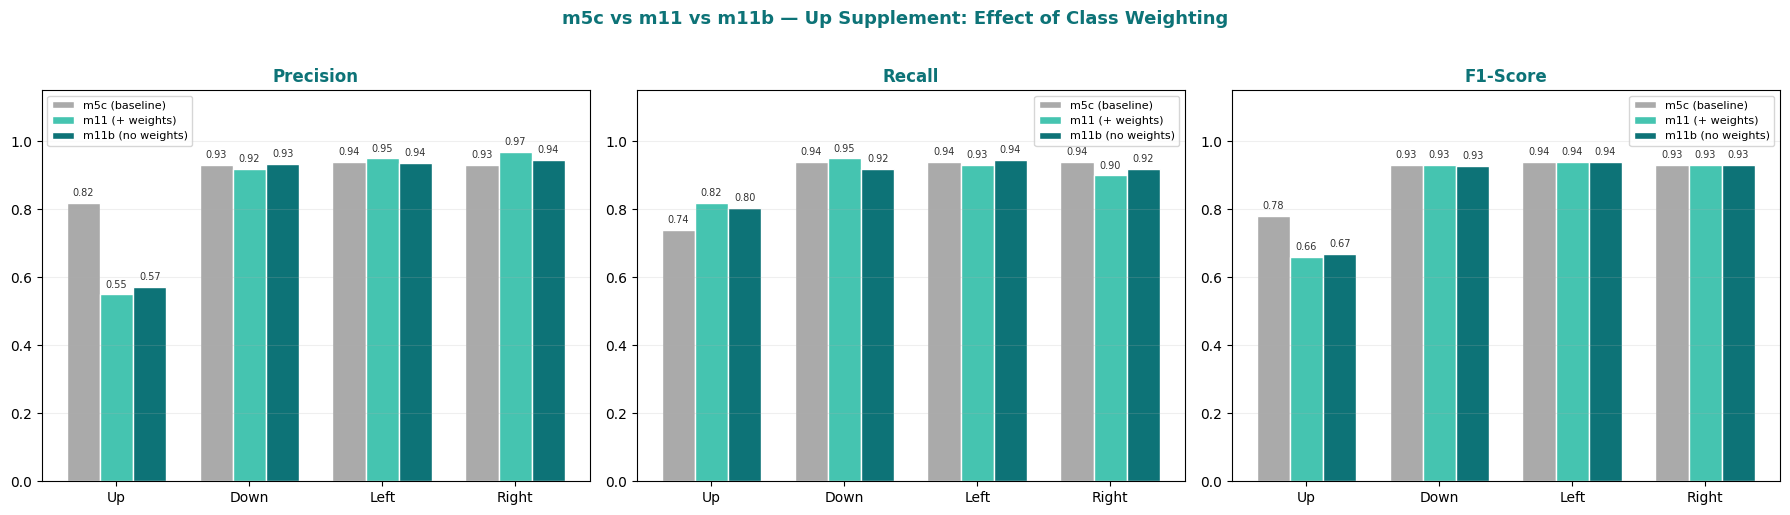


Per-Class Delta vs m5c (positive = better than baseline)
Class      m11 Prec  m11b Prec   m11 Rec  m11b Rec   m11 F1  m11b F1
----------------------------------------------------------------------
Up           -0.270     -0.247    +0.080    +0.064   -0.120   -0.111
Down         -0.010     +0.005    +0.010    -0.021   +0.000   -0.003
Left         +0.010     -0.003    -0.010    +0.005   +0.000   +0.001
Right        +0.040     +0.015    -0.040    -0.021   +0.000   +0.001


In [19]:
# ============================================================
# m5c vs m11 vs m11b COMPARISON
# Shows the effect of supplement data with and without weights.
# ============================================================

m5c_report = {
    'Up':    {'precision': 0.82, 'recall': 0.74, 'f1': 0.78},
    'Down':  {'precision': 0.93, 'recall': 0.94, 'f1': 0.93},
    'Left':  {'precision': 0.94, 'recall': 0.94, 'f1': 0.94},
    'Right': {'precision': 0.93, 'recall': 0.94, 'f1': 0.93},
}

m11_report = {
    'Up':    {'precision': 0.55, 'recall': 0.82, 'f1': 0.66},
    'Down':  {'precision': 0.92, 'recall': 0.95, 'f1': 0.93},
    'Left':  {'precision': 0.95, 'recall': 0.93, 'f1': 0.94},
    'Right': {'precision': 0.97, 'recall': 0.90, 'f1': 0.93},
}

p, r, f, s = precision_recall_fscore_support(all_labels, all_preds, labels=[0,1,2,3])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(4)
width = 0.25

for ax, key, m11b_vals, title in [
    (axes[0], 'precision', p, 'Precision'),
    (axes[1], 'recall',    r, 'Recall'),
    (axes[2], 'f1',        f, 'F1-Score'),
]:
    m5c_vals = [m5c_report[c][key] for c in label_names]
    m11_vals = [m11_report[c][key] for c in label_names]

    bars1 = ax.bar(x - width, m5c_vals,   width, label='m5c (baseline)',      color='#AAAAAA', edgecolor='white')
    bars2 = ax.bar(x,         m11_vals,   width, label='m11 (+ weights)',     color='#45C4B0', edgecolor='white')
    bars3 = ax.bar(x + width, m11b_vals,  width, label='m11b (no weights)',   color='#0D7377', edgecolor='white')

    ax.set_xticks(x); ax.set_xticklabels(label_names)
    ax.set_ylim(0, 1.15)
    ax.set_title(title, fontweight='bold', color='#0D7377')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{bar.get_height():.2f}', ha='center', fontsize=7, color='#333333')

plt.suptitle('m5c vs m11 vs m11b — Up Supplement: Effect of Class Weighting',
             fontsize=13, fontweight='bold', color='#0D7377', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Per-Class Delta vs m5c (positive = better than baseline)")
print("="*70)
print(f"{'Class':8s} {'m11 Prec':>10s} {'m11b Prec':>10s} {'m11 Rec':>9s} {'m11b Rec':>9s} {'m11 F1':>8s} {'m11b F1':>8s}")
print("-"*70)
for i, name in enumerate(label_names):
    m11p  = m11_report[name]['precision'] - m5c_report[name]['precision']
    m11bp = p[i] - m5c_report[name]['precision']
    m11r  = m11_report[name]['recall'] - m5c_report[name]['recall']
    m11br = r[i] - m5c_report[name]['recall']
    m11f  = m11_report[name]['f1'] - m5c_report[name]['f1']
    m11bf = f[i] - m5c_report[name]['f1']
    print(f"{name:8s} {m11p:>+10.3f} {m11bp:>+10.3f} {m11r:>+9.3f} {m11br:>+9.3f} {m11f:>+8.3f} {m11bf:>+8.3f}")
print("="*70)

In [20]:
# ============================================================
# SAVE TRAINING CURVES & CONFIRM CHECKPOINTS
# ============================================================

print("train_losses_m11b =", train_losses)
print("val_losses_m11b =", val_losses)
print("train_acc_m11b =", train_accuracies)
print("val_acc_m11b =", val_accuracies)

print(f"\nCheckpoint (_best):    {os.path.exists(CHECKPOINT_BEST)} — "
      f"{os.path.getsize(CHECKPOINT_BEST)/1e6:.1f} MB")
print(f"Checkpoint (_bestgap): {os.path.exists(CHECKPOINT_BESTGAP)} — "
      f"{os.path.getsize(CHECKPOINT_BESTGAP)/1e6:.1f} MB")

train_losses_m11b = [0.722396762476535, 0.5652527645161843, 0.5202119510069516, 0.4948550684380155, 0.47699409915535707, 0.4642058352772195, 0.45481399671270006, 0.42897733281133466, 0.42171094341741866]
val_losses_m11b = [0.5825175654416704, 0.5488095752263473, 0.5163420553261278, 0.5381649180320697, 0.5294595371531902, 0.5417795875314939, 0.5565179928211169, 0.5273921771238079, 0.5310857201700157]
train_acc_m11b = [81.51156112664802, 90.10687175389532, 92.29487115461447, 93.5333849380743, 94.37986915701158, 95.0253445864962, 95.43173192169397, 96.69708849380743, 97.09411206552137]
val_acc_m11b = [89.15564670108196, 90.13153242344954, 91.97369351531009, 90.69726327699597, 90.99427197510784, 90.48865002475073, 89.87341772151899, 91.18167032034509, 91.08266742097447]

Checkpoint (_best):    True — 26.4 MB
Checkpoint (_bestgap): True — 26.4 MB
